In [2]:
# =========================================================
# MOUNT GOOGLE DRIVE
# =========================================================

from google.colab import drive

drive.mount('/content/drive')

print("✅ Drive mounted.")

Mounted at /content/drive
✅ Drive mounted.


In [3]:
# =========================================================
# INSTALL LIBRARIES
# =========================================================

!pip install -q faiss-cpu
!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00


In [4]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import os
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

import torch

import faiss

import open_clip

print("✅ Libraries imported.")

✅ Libraries imported.


In [5]:
# =========================================================
# CONFIG
# =========================================================

PROJECT_ROOT = "/content/drive/MyDrive/PersonalFashionStylistV2"

CONFIG = {

    "embeddings_path": os.path.join(
        PROJECT_ROOT,
        "embeddings",
        "clip_embeddings.npy"
    ),

    "metadata_path": os.path.join(
        PROJECT_ROOT,
        "embeddings",
        "embedding_metadata.csv"
    ),

    "faiss_index_path": os.path.join(
        PROJECT_ROOT,
        "faiss",
        "fashion_faiss.index"
    ),

    "top_k": 5
}

print("✅ Config initialized.")

✅ Config initialized.


In [6]:
# =========================================================
# LOAD EMBEDDINGS
# =========================================================

embeddings = np.load(
    CONFIG["embeddings_path"]
)

metadata_df = pd.read_csv(
    CONFIG["metadata_path"]
)

print("✅ Data loaded.")

print("Embeddings:", embeddings.shape)

print("Metadata:", len(metadata_df))

✅ Data loaded.
Embeddings: (44074, 512)
Metadata: 44074


In [7]:
# =========================================================
# DOWNLOAD DATASET
# =========================================================

import kagglehub

fashion_products_path = kagglehub.dataset_download(
    "paramaggarwal/fashion-product-images-small"
)

print("✅ Dataset ready.")

100%|██████████| 565M/565M [00:05<00:00, 108MB/s] 

Extracting files...


✅ Dataset ready.


In [8]:
# =========================================================
# FIX IMAGE PATHS
# =========================================================

real_image_dir = os.path.join(
    fashion_products_path,
    "images"
)

def fix_inventory_path(old_path):

    filename = os.path.basename(old_path)

    return os.path.join(
        real_image_dir,
        filename
    )

metadata_df["image_path"] = metadata_df["image_path"].apply(
    fix_inventory_path
)

print("✅ Metadata paths fixed.")

✅ Metadata paths fixed.


In [9]:
# =========================================================
# LOAD FAISS INDEX
# =========================================================

index = faiss.read_index(
    CONFIG["faiss_index_path"]
)

print("✅ FAISS index loaded.")

✅ FAISS index loaded.


In [10]:
# =========================================================
# DEVICE + OPENCLIP
# =========================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model, _, preprocess = open_clip.create_model_and_transforms(

    "ViT-B-32",

    pretrained="laion2b_s34b_b79k"
)

model = model.to(device)

model.eval()

print("✅ OpenCLIP loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

✅ OpenCLIP loaded.


In [11]:
# =========================================================
# QUERY EMBEDDING FUNCTION
# =========================================================

def generate_query_embedding(image_path):

    image = Image.open(image_path).convert("RGB")

    image = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():

        embedding = model.encode_image(image)

        embedding = embedding / embedding.norm(
            dim=-1,
            keepdim=True
        )

    return embedding.cpu().numpy()

In [24]:
# =========================================================
# IMPROVED SMART RETRIEVAL
# =========================================================

def smart_retrieve(

    query_image_path,

    top_k=5,

    gender_filter=None,

    category_filter=None,

    min_similarity=0.25
):

    # ======================================
    # Generate Query Embedding
    # ======================================

    query_embedding = generate_query_embedding(
        query_image_path
    )

    # ======================================
    # Retrieve Larger Candidate Pool
    # ======================================

    similarities, indices = index.search(

        query_embedding.astype(np.float32),

        300
    )

    candidate_df = metadata_df.iloc[
        indices[0]
    ].copy()

    candidate_df["similarity"] = similarities[0]

    # ======================================
    # Similarity Threshold
    # ======================================

    candidate_df = candidate_df[

        candidate_df["similarity"] >= min_similarity
    ]

    # ======================================
    # Gender Filtering
    # ======================================

    if gender_filter is not None:

        candidate_df = candidate_df[
            candidate_df["gender"] == gender_filter
        ]

    # ======================================
    # Category Filtering
    # ======================================

    if category_filter is not None:

        candidate_df = candidate_df[
            candidate_df["masterCategory"] == category_filter
        ]

    # ======================================
    # Duplicate Suppression
    # ======================================

    candidate_df = candidate_df.drop_duplicates(
        subset=["articleType"]
    )

    # ======================================
    # Final Top-K
    # ======================================

    candidate_df = candidate_df.head(top_k)

    return candidate_df

In [27]:
# =========================================================
# TEST SMART RETRIEVAL
# =========================================================

query_image_path = metadata_df.iloc[100]["image_path"]

results = smart_retrieve(

    query_image_path,

    top_k=5,

    gender_filter="Men",

    category_filter="Footwear",

    min_similarity=0.15
)
print("✅ Smart retrieval complete.")

results[[
    "gender",
    "masterCategory",
    "articleType",
    "baseColour",
    "usage"
]]

✅ Smart retrieval complete.


,gender,masterCategory,articleType,baseColour,usage
100,Men,Footwear,Casual Shoes,White,Casual
31298,Men,Footwear,Sports Shoes,White,Sports
15278,Men,Footwear,Sandals,Blue,Casual
9364,Men,Footwear,Sports Sandals,Black,Casual


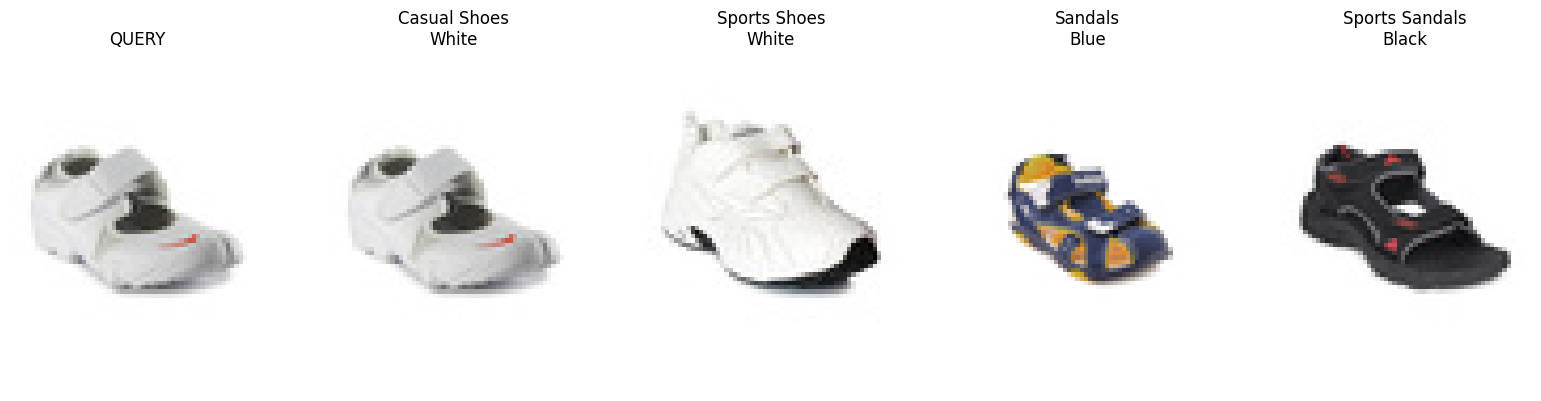

In [28]:
# =========================================================
# VISUALIZE SMART RETRIEVAL
# =========================================================

plt.figure(figsize=(16, 4))

# ==========================
# QUERY IMAGE
# ==========================

query_image = Image.open(
    query_image_path
).convert("RGB")

plt.subplot(1, len(results) + 1, 1)

plt.imshow(query_image)

plt.title("QUERY")

plt.axis("off")

# ==========================
# RETRIEVED RESULTS
# ==========================

for i, (_, row) in enumerate(results.iterrows()):

    result_image = Image.open(
        row["image_path"]
    ).convert("RGB")

    plt.subplot(
        1,
        len(results) + 1,
        i + 2
    )

    plt.imshow(result_image)

    plt.title(
        f"{row['articleType']}\n{row['baseColour']}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()